In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import yaml
import pandas as pd

from IPython.display import Image, display

from data_models import Asset
from fed_watch_graph import FedWatchGraph, FedWatchState

In [3]:
from dotenv import load_dotenv

if load_dotenv():
    print("Environment variables loaded.")
else:
    print("No .env file found or failed to load.")

Environment variables loaded.


In [4]:
# Read assets from a YAML file

with open("../data/assets.yml", "r") as file:
    assets = yaml.safe_load(file)

print(assets)

{'asset_001': {'asset': '24K-999 Gold', 'description': 'Pure 24K gold bar for investment purposes', 'asset_class': 'Precious Metals', 'industry': 'Commodities', 'market': 'Global', 'quantity': 10, 'investment_unit': 'gram', 'buy_price_per_unit': 90, 'currency': 'SGD', 'date': '2024-01-15'}, 'asset_002': {'asset': 'Vanguard Information Technology Index Fund VGT ETF', 'description': 'ETF focusing on technology sector stocks', 'asset_class': 'Exchange Traded Funds', 'industry': 'Technology', 'market': 'US', 'quantity': 10, 'investment_unit': 'share', 'buy_price_per_unit': 550, 'currency': 'USD', 'date': '2024-07-15'}, 'asset_003': {'asset': 'CapitaLand Integrated Commercial Trust', 'description': 'REITs focused on commercial properties in Singapore', 'asset_class': 'REITs', 'industry': 'Real Estate', 'market': 'Singapore', 'quantity': 1000, 'investment_unit': 'share', 'buy_price_per_unit': 1.98, 'currency': 'SGD', 'date': '2022-12-15'}, 'asset_004': {'asset': '24K-999 Gold', 'description'

In [5]:
# Prepare a dataframe with input asset information

asset_df = (
    pd.DataFrame.from_dict(assets, orient="index")
    .reset_index()
    .rename(columns={"index": "asset_id"})
)

print(asset_df.shape)
asset_df.head()

(4, 11)


,asset_id,asset,description,asset_class,industry,market,quantity,investment_unit,buy_price_per_unit,currency,date
0,asset_001,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,10,gram,90.00,SGD,2024-01-15
1,asset_002,Vanguard Information Technology Index Fund VGT...,ETF focusing on technology sector stocks,Exchange Traded Funds,Technology,US,10,share,550.00,USD,2024-07-15
2,asset_003,CapitaLand Integrated Commercial Trust,REITs focused on commercial properties in Sing...,REITs,Real Estate,Singapore,1000,share,1.98,SGD,2022-12-15
3,asset_004,24K-999 Gold,Pure 24K gold bar for investment purposes,Precious Metals,Commodities,Global,50,gram,180.00,SGD,2025-12-15


In [6]:
# Load unique assets

unique_assets = asset_df["asset"].unique()
print(unique_assets)

['24K-999 Gold' 'Vanguard Information Technology Index Fund VGT ETF'
 'CapitaLand Integrated Commercial Trust']


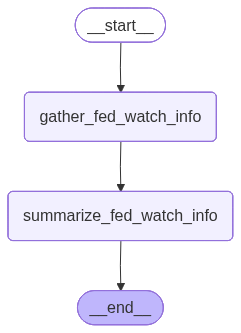

In [7]:
# Load the agent for collecting fed watch information
fed_watch_graph = FedWatchGraph().contruct_graph().compile()

# Image(fed_watch_graph.get_graph().draw_png())
display(Image(fed_watch_graph.get_graph(xray=True).draw_mermaid_png()))

In [8]:
# Run the agent to get information about the fed rate changes

state = FedWatchState(assets=unique_assets.tolist())
result = None

thread = {"configurable": {"thread_id": "1"}}

for chunk in fed_watch_graph.stream(state, thread=thread, stream_mode="values"):
    print("\n\nNew Chunk Received:\n")
    if "messages" in chunk:
        for m in chunk["messages"]:
            m.pretty_print()
    if "fed_watch_info" in chunk:
        print("\n\nCompiled Fed Watch Information:")
        print(chunk["fed_watch_info"])
        result = chunk["fed_watch_info"]



New Chunk Received:



New Chunk Received:



New Chunk Received:



Compiled Fed Watch Information:
[FedWatchInfo(current_fed_rate=3.625, next_meeting_date='March 17-18, 2026', expected_rate_change='No Change', personal_finance_impact='The Fed is expected to hold the federal funds target at 3.50%–3.75% at the next FOMC meeting, so short-term borrowing costs and benchmark-driven rates should remain broadly stable. For your assets: gold (24K-999) may be supported if expectations for eventual rate cuts re-emerge (safe-haven appeal and lower real yields); VGT (information-technology ETF) is interest-rate sensitive—stable rates are neutral-to-supportive for growth stocks, while eventual cuts could boost valuations; CapitaLand Integrated Commercial Trust (a commercial REIT) benefits from stable or falling rates (lower financing costs and yield compression), whereas sustained higher rates would be a headwind. More generally, mortgage and loan rates will likely stay elevated until cuts mate